# Experiment — RNN


## 1. Setup

In [1]:
from google.colab import files
print("Upload sentiment-analysis-on-movie-reviews.zip:")
uploaded = files.upload()

Upload sentiment-analysis-on-movie-reviews.zip:


Saving sentiment-analysis-on-movie-reviews.zip to sentiment-analysis-on-movie-reviews.zip


In [2]:
!unzip -o sentiment-analysis-on-movie-reviews.zip -d data/
!unzip -o data/train.tsv.zip -d data/
!unzip -o data/test.tsv.zip  -d data/
!ls data/

Archive:  sentiment-analysis-on-movie-reviews.zip
  inflating: data/sampleSubmission.csv  
  inflating: data/test.tsv.zip       
  inflating: data/train.tsv.zip      
Archive:  data/train.tsv.zip
  inflating: data/train.tsv          
Archive:  data/test.tsv.zip
  inflating: data/test.tsv           
sampleSubmission.csv  test.tsv	test.tsv.zip  train.tsv  train.tsv.zip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Preprocessing

In [4]:
train_df = pd.read_csv('data/train.tsv', sep='\t')
test_df  = pd.read_csv('data/test.tsv',  sep='\t')

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r"[^a-z\s']", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean'] = train_df['Phrase'].apply(clean_text)
test_df['clean']  = test_df['Phrase'].apply(clean_text)

In [5]:
MIN_FREQ  = 2
MAX_LEN   = 50
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

freq  = Counter(' '.join(train_df['clean']).split())
vocab = [PAD_TOKEN, UNK_TOKEN] + [w for w, c in freq.items() if c >= MIN_FREQ]
word2idx = {w: i for i, w in enumerate(vocab)}
print(f'Vocabulary size: {len(vocab)}')

def encode(text, max_len=MAX_LEN):
    tokens = text.split()[:max_len]
    ids    = [word2idx.get(t, 1) for t in tokens]
    ids   += [0] * (max_len - len(ids))
    return ids

train_df['encoded'] = train_df['clean'].apply(encode)
test_df['encoded']  = test_df['clean'].apply(encode)

Vocabulary size: 16198


## 3. Dataset & DataLoader

In [6]:
class PhraseDataset(Dataset):
    def __init__(self, encodings, labels=None):
        self.X = torch.tensor(encodings, dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long) if labels is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

In [7]:
X = list(train_df['encoded'])
y = list(train_df['Sentiment'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=SEED, stratify=y)

BATCH_SIZE = 128

train_loader = DataLoader(PhraseDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(PhraseDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(PhraseDataset(list(test_df['encoded'])), batch_size=BATCH_SIZE)

## 4. Model — Simple RNN


In [14]:
class RNNBlock(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout   = nn.Dropout(dropout)
        self.rnn       = nn.RNN(
            embed_dim, hidden_dim,
            num_layers=1,
            batch_first=True,
            nonlinearity='relu'
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, hidden = self.rnn(emb)
        return self.fc(self.dropout(hidden[-1]))

In [15]:
VOCAB_SIZE  = len(vocab)
EMBED_DIM   = 128
HIDDEN_DIM  = 256
NUM_CLASSES = 5
DROPOUT     = 0.3
EPOCHS      = 10
LR          = 1e-3

model     = RNNBlock(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, DROPOUT).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

RNNBlock(
  (embedding): Embedding(16198, 128, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (rnn): RNN(128, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=5, bias=True)
)

Trainable parameters: 2,173,445


## 5. Training

In [16]:
history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (out.argmax(1) == y_batch).sum().item()
    tr_loss = total_loss / len(train_loader.dataset)
    tr_acc  = correct   / len(train_loader.dataset)

    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out  = model(X_batch)
            loss = criterion(out, y_batch)
            total_loss += loss.item() * len(y_batch)
            correct    += (out.argmax(1) == y_batch).sum().item()
    vl_loss = total_loss / len(val_loader.dataset)
    vl_acc  = correct   / len(val_loader.dataset)

    scheduler.step(vl_loss)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_rnn_model.pt')

    print(f'Epoch {epoch:02d} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch 01 | Train Loss: 1.2933 Acc: 0.5091 | Val Loss: 1.2840 Acc: 0.5099
Epoch 02 | Train Loss: 1.2998 Acc: 0.5096 | Val Loss: 1.2847 Acc: 0.5099
Epoch 03 | Train Loss: 1.2859 Acc: 0.5100 | Val Loss: 1.2878 Acc: 0.5099
Epoch 04 | Train Loss: 1.2868 Acc: 0.5099 | Val Loss: 1.2838 Acc: 0.5099
Epoch 05 | Train Loss: 1.2853 Acc: 0.5100 | Val Loss: 1.2837 Acc: 0.5099
Epoch 06 | Train Loss: 1.2849 Acc: 0.5094 | Val Loss: 1.2464 Acc: 0.5118
Epoch 07 | Train Loss: 1.2077 Acc: 0.5189 | Val Loss: 1.1551 Acc: 0.5407
Epoch 08 | Train Loss: 1.1390 Acc: 0.5467 | Val Loss: 1.1170 Acc: 0.5546
Epoch 09 | Train Loss: 1.0880 Acc: 0.5645 | Val Loss: 1.0671 Acc: 0.5777
Epoch 10 | Train Loss: 1.0544 Acc: 0.5764 | Val Loss: 1.0440 Acc: 0.5791

Best Val Accuracy: 0.5791


## 6. Validation & Evaluation

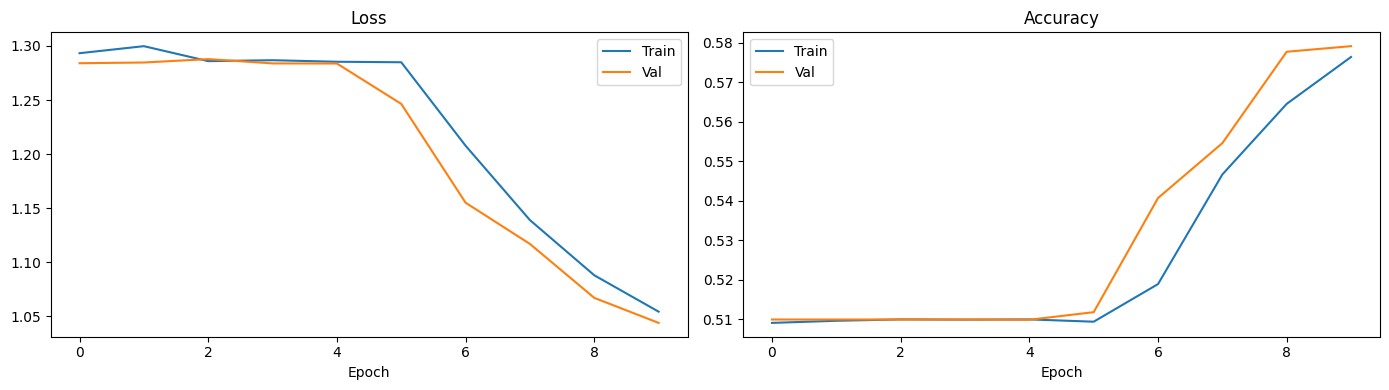

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
label_names = {0: 'Negative', 1: 'Somewhat Neg', 2: 'Neutral', 3: 'Somewhat Pos', 4: 'Positive'}

model.load_state_dict(torch.load('best_rnn_model.pt', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds, target_names=list(label_names.values())))

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       707
Somewhat Neg       0.29      0.13      0.18      2727
     Neutral       0.63      0.91      0.75      7958
Somewhat Pos       0.50      0.39      0.44      3293
    Positive       0.52      0.14      0.23       921

    accuracy                           0.58     15606
   macro avg       0.39      0.32      0.32     15606
weighted avg       0.51      0.58      0.52     15606



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 7. Test Predictions

In [19]:
model.eval()
test_preds = []
with torch.no_grad():
    for X_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(1).cpu().numpy()
        test_preds.extend(preds)

submission = pd.DataFrame({'PhraseId': test_df['PhraseId'], 'Sentiment': test_preds})
submission.to_csv('submission_rnn.csv', index=False)
print('submission_rnn.csv saved')
submission.head()

submission_rnn.csv saved


,PhraseId,Sentiment
0,156061,1
1,156062,1
2,156063,2
3,156064,2
4,156065,2
